In [8]:
from random import randint
from typing import TypedDict, Literal

from langchain.agents import create_agent
from langchain_classic.chains.question_answering.map_reduce_prompt import messages
from langchain_core.messages import ToolMessage, SystemMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.types import Command
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain.messages import HumanMessage
from rich import print as rprint

from dotenv import load_dotenv
load_dotenv(override=True)

model = ChatOpenAI(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)


@tool(parse_docstring=True)
def get_weather(city: str="上海"):
    """
    查询指定城市当日天气

    Args:
        city: 城市名称
    """
    return f"{city}的天气是晴朗的"

@tool(parse_docstring=True)
def get_news(domain: Literal["AI", "食品安全"]):
    """
    查询特定领域的当日热点

    Args:
        domain: 特定领域
    """
    if domain == "AI":
        return "Anthropic 发布了 Claude Opus-4.8，但通过 API 用中文向它发送“你是谁？”时，大多数情况下返回的却是“Qwen”或“Deepseek”。"
    else:
        return "双汇发展子公司猪肉产品被抽检出抗生素超标37.5倍"

tools = [get_weather, get_news]

# model 不会主动调用工具，只会返回需要调用的工具的信息
model_with_model = model.bind_tools(tools=tools)
#
# res = model_with_model.invoke(input="上海的天气和AI领域的新闻？")
#
# rprint(res)

# agent自动调用工具
# agent = create_agent(
#     model=model,
#     tools=tools
# )
#
# res = agent.invoke({
#     "messages": [
#         HumanMessage("上海的天气和AI领域的新闻")
#     ]
# })
#
# rprint(res)


In [11]:
class OverAllState(MessagesState):
    user_input: str
    final_output: str

# 输入节点
def input_node(state: OverAllState) -> OverAllState:
    return {
        "messages": [
            HumanMessage(state["user_input"])
        ]
    }

def llm_node(state: OverAllState) -> OverAllState:
    ai_msg = model_with_model.invoke(state["messages"])
    return {
        "messages": [ai_msg]
    }

def tool_node(state: OverAllState) -> OverAllState:
    messages = state["messages"]
    ai_msg = messages[-1]
    tool_calls = ai_msg.tool_calls

    fail_prob = 6 # 失败概率，6表示 60% 概率失败，7 -> 70%，8 -> 80%，依次类推

    for tool_call in tool_calls:
        if tool_call["name"] == "get_weather":
            # 生成 [0, 9] 范围内的随机数
            if randint(0, 9) < fail_prob: # 60% 概率因 “网络波动” 而调用失败
                messages.append(
                    ToolMessage(
                        content="网络波动，调用失败，请重试",
                        tool_call_id=tool_call["id"]
                    )
                )
            else:
                messages.append(get_weather.invoke(tool_call))
        elif tool_call["name"] == "get_news":
            # 生成 [0, 9] 范围内的随机数
            if randint(0, 9) < fail_prob: # 60% 概率因 “网络波动” 而调用失败
                messages.append(
                    ToolMessage(
                        content="网络波动，调用失败，请重试",
                        tool_call_id=tool_call["id"]
                    )
                )
            else:
                messages.append(get_news.invoke(tool_call))
        else:
            messages.append(
                ToolMessage(
                    content="工具名称错误，调用失败，请重试",
                    tool_call_id=tool_call["id"]
                )
            )

    return {
        "messages": messages
    }

def output_node(state: OverAllState) -> OverAllState:
    return {
        "final_output": state["messages"][-1].content
    }

def router(state: OverAllState) -> Literal["tool_node", "output_node"]:
    messages = state["messages"]
    last_msg = messages[-1]
    if last_msg.tool_calls:
        return "tool_node"
    return "output_node"
# 构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("input_node", input_node)
builder.add_node("llm_node", llm_node)
builder.add_node("tool_node",tool_node)
builder.add_node("output_node",output_node)

builder.add_edge(START, "input_node")
builder.add_edge("input_node", "llm_node")
builder.add_conditional_edges("llm_node", router)
builder.add_edge("tool_node", "llm_node")
builder.add_edge("output_node", END)

graph = builder.compile()

ai_res = graph.invoke({
    "user_input": "帮我查询杭州当日天气和AI热点",
    "messages": [SystemMessage("如果工具调用失败，必须重新调用直至成功")]
})

rprint(ai_res)







{
    'messages': [
        SystemMessage(
            content='如果工具调用失败，必须重新调用直至成功',
            additional_kwargs={},
            response_metadata={},
            id='cf483d79-692d-4435-bf86-84cdb06c7d99'
        ),
        HumanMessage(
            content='帮我查询杭州当日天气和AI热点',
            additional_kwargs={},
            response_metadata={},
            id='bbf966af-27cb-45fb-a1a7-5268d387bfab'
        ),
        AIMessage(
            content='好的，我来同时查询杭州的天气和AI热点信息',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 88,
                    'prompt_tokens': 361,
                    'total_tokens': 449,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': None,
                'id': 'chatcmpl-5752f316-9b54-9e01-ae8b-21592fc17a6a',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a08955-94d7-77e1-a273-d4b90780a444-0',
            tool_calls=[
                {
                    'name': 'get_weather',
                    'args': {'city': '杭州'},
                    'id': 'call_8b218e6e32ca4b5fbf4885d9',
                    'type': 'tool_call'
                },
                {
                    'name': 'get_news',
                    'args': {'domain': 'AI'},
                    'id': 'call_c8583447ef5c4facb25980cf',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 361,
                'output_tokens': 88,
                'total_tokens': 449,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='网络波动，调用失败，请重试',
            id='fd889c6c-eb5e-4eec-838f-0b01ecc7e89b',
            tool_call_id='call_8b218e6e32ca4b5fbf4885d9'
        ),
        ToolMessage(
            content='网络波动，调用失败，请重试',
            id='a5d46dca-1c0a-45e6-a733-24d1fd816853',
            tool_call_id='call_c8583447ef5c4facb25980cf'
        ),
        AIMessage(
            content='看起来网络波动导致查询都失败了，我重新尝试一下',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 87,
                    'prompt_tokens': 486,
                    'total_tokens': 573,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': None,
                'id': 'chatcmpl-552a64b9-c669-95aa-a629-887046889e97',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a08955-9f97-7ea0-be6e-cf3f1ad27a6f-0',
            tool_calls=[
                {
                    'name': 'get_weather',
                    'args': {'city': '杭州'},
                    'id': 'call_b947c9b63c88415da8c0517b',
                    'type': 'tool_call'
                },
                {
                    'name': 'get_news',
                    'args': {'domain': 'AI'},
                    'id': 'call_edc5ee99faaf460d9bd9d65a',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 486,
                'output_tokens': 87,
                'total_tokens': 573,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
  

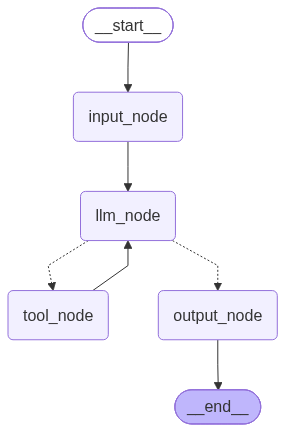

In [12]:
from IPython.display import display
display(graph)